In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data and models
from sklearn.datasets import make_friedman1, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# A simple 1D regression problem is the clearest way to show residual fitting.
n_samples = 300
X = np.sort(np.random.rand(n_samples, 1) * 10, axis=0)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(scale=0.25, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 210
Test samples: 90


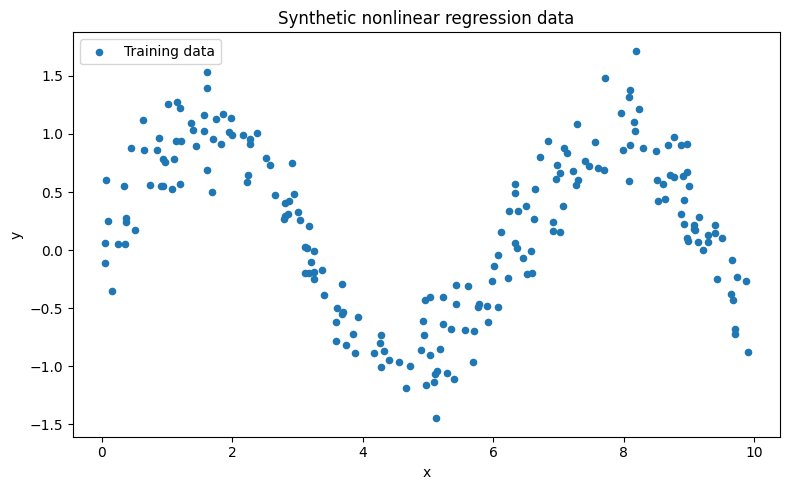

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=20, label="Training data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic nonlinear regression data")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def regression_metrics(y_true, y_pred):
    """Return a small set of regression metrics."""
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }


def evaluate_regressor(model, X_train, X_test, y_train, y_test):
    """
    Fit a regression model and return train/test metrics.
    Keeping both helps show when the model starts to overfit.
    """
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    return {
        "train_rmse": train_metrics["rmse"],
        "test_rmse": test_metrics["rmse"],
        "train_r2": train_metrics["r2"],
        "test_r2": test_metrics["r2"],
    }

In [ ]:
# A shallow tree is a good weak learner because it captures only simple structure.
weak_tree = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)

baseline_metrics = evaluate_regressor(
    weak_tree, X_train, X_test, y_train, y_test
)

pd.DataFrame([{"model": "Decision stump", **baseline_metrics}])

,model,train_rmse,test_rmse,train_r2,test_r2
0,Decision stump,0.607688,0.559837,0.21974,0.151116


In [ ]:
# Start with a simple constant prediction: the mean of the training targets.
F0 = np.full_like(y_train, fill_value=np.mean(y_train), dtype=float)

# Residuals are what the current model still gets wrong.
residuals_1 = y_train - F0

# Fit a weak learner to those residuals.
tree_1 = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
tree_1.fit(X_train, residuals_1)

# Use a learning rate so each step is small and controlled.
learning_rate = 0.1
F1 = F0 + learning_rate * tree_1.predict(X_train)

# Fit a second weak learner to the new residuals.
residuals_2 = y_train - F1
tree_2 = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
tree_2.fit(X_train, residuals_2)

F2 = F1 + learning_rate * tree_2.predict(X_train)

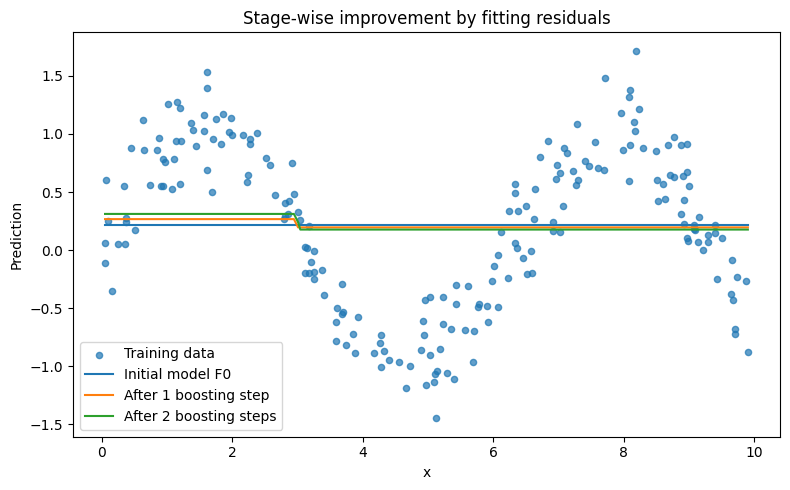

In [ ]:
# Sort x-values for smooth plotting
sort_idx = np.argsort(X_train[:, 0])
X_train_sorted = X_train[sort_idx]
y_train_sorted = y_train[sort_idx]
F0_sorted = F0[sort_idx]
F1_sorted = F1[sort_idx]
F2_sorted = F2[sort_idx]

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=20, alpha=0.7, label="Training data")
plt.plot(X_train_sorted, F0_sorted, label="Initial model F0")
plt.plot(X_train_sorted, F1_sorted, label="After 1 boosting step")
plt.plot(X_train_sorted, F2_sorted, label="After 2 boosting steps")
plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Stage-wise improvement by fitting residuals")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=1,
    random_state=RANDOM_STATE
)

gbr_metrics = evaluate_regressor(
    gbr, X_train, X_test, y_train, y_test
)

pd.DataFrame([
    {"model": "Decision stump", **baseline_metrics},
    {"model": "Gradient boosting", **gbr_metrics}
])

,model,train_rmse,test_rmse,train_r2,test_r2
0,Decision stump,0.607688,0.559837,0.21974,0.151116
1,Gradient boosting,0.337077,0.299670,0.75993,0.756774


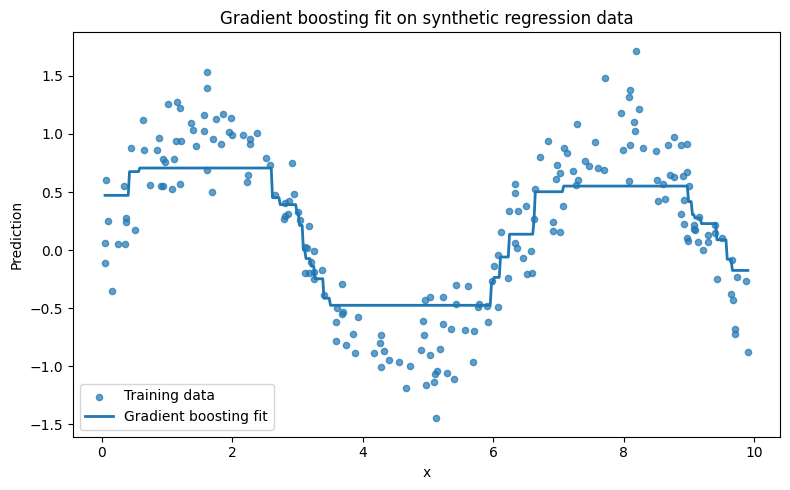

In [ ]:
gbr.fit(X_train, y_train)

X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_plot_pred = gbr.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=20, alpha=0.7, label="Training data")
plt.plot(X_plot, y_plot_pred, linewidth=2, label="Gradient boosting fit")
plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Gradient boosting fit on synthetic regression data")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# This experiment shows how error changes as boosting stages are added.
estimator_values = [1, 5, 10, 20, 50, 100, 200]
rows = []

for n in estimator_values:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=1,
        random_state=RANDOM_STATE
    )

    metrics = evaluate_regressor(model, X_train, X_test, y_train, y_test)
    rows.append({
        "n_estimators": n,
        **metrics
    })

estimator_df = pd.DataFrame(rows)
estimator_df

,n_estimators,train_rmse,test_rmse,train_r2,test_r2
0,1,0.673442,0.594439,0.041751,0.042940
1,5,0.633476,0.557414,0.152112,0.158447
2,10,0.594602,0.520998,0.252983,0.264812
3,20,0.534452,0.466553,0.396474,0.410441
4,50,0.428424,0.372475,0.612183,0.624233
5,100,0.337077,0.299670,0.759930,0.756774
6,200,0.264579,0.256100,0.852093,0.822359


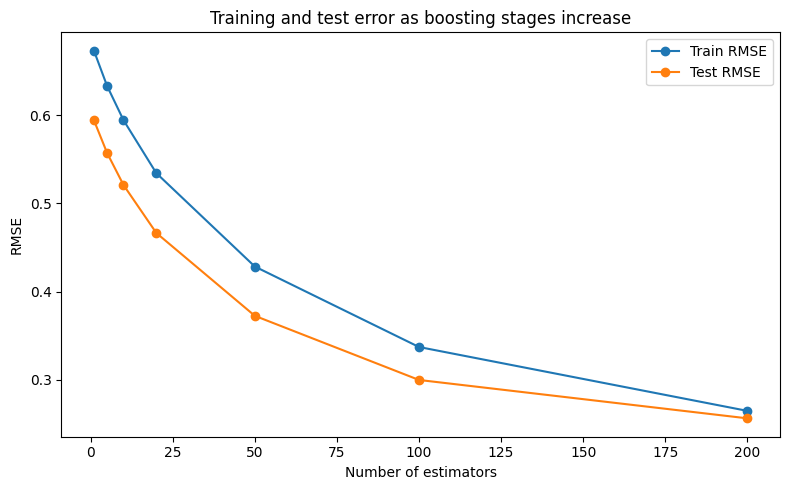

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(estimator_df["n_estimators"], estimator_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(estimator_df["n_estimators"], estimator_df["test_rmse"], marker="o", label="Test RMSE")
plt.xlabel("Number of estimators")
plt.ylabel("RMSE")
plt.title("Training and test error as boosting stages increase")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Smaller learning rates usually need more estimators, but they often generalise better.
learning_rates = [0.01, 0.05, 0.1, 0.3]
lr_rows = []

for lr in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=1,
        random_state=RANDOM_STATE
    )

    metrics = evaluate_regressor(model, X_train, X_test, y_train, y_test)
    lr_rows.append({
        "learning_rate": lr,
        **metrics
    })

lr_df = pd.DataFrame(lr_rows)
lr_df

,learning_rate,train_rmse,test_rmse,train_r2,test_r2
0,0.01,0.597531,0.524323,0.245605,0.255400
1,0.05,0.431640,0.375671,0.606339,0.617756
2,0.10,0.337077,0.299670,0.759930,0.756774
3,0.30,0.233016,0.245599,0.885278,0.836628


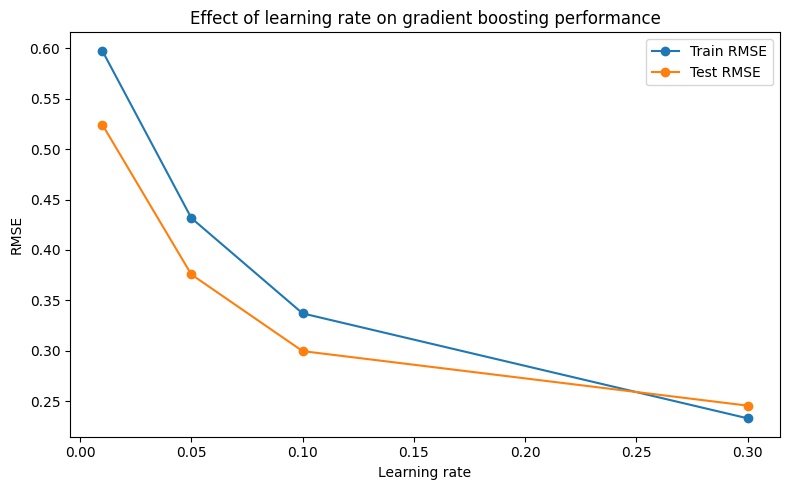

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(lr_df["learning_rate"], lr_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(lr_df["learning_rate"], lr_df["test_rmse"], marker="o", label="Test RMSE")
plt.xlabel("Learning rate")
plt.ylabel("RMSE")
plt.title("Effect of learning rate on gradient boosting performance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Depth controls how complex each weak learner can be.
depth_values = [1, 2, 3, 4]
depth_rows = []

for depth in depth_values:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    metrics = evaluate_regressor(model, X_train, X_test, y_train, y_test)
    depth_rows.append({
        "max_depth": depth,
        **metrics
    })

depth_df = pd.DataFrame(depth_rows)
depth_df

,max_depth,train_rmse,test_rmse,train_r2,test_r2
0,1,0.337077,0.299670,0.759930,0.756774
1,2,0.199261,0.248668,0.916107,0.832519
2,3,0.160311,0.255810,0.945699,0.822760
3,4,0.118495,0.265023,0.970333,0.809764


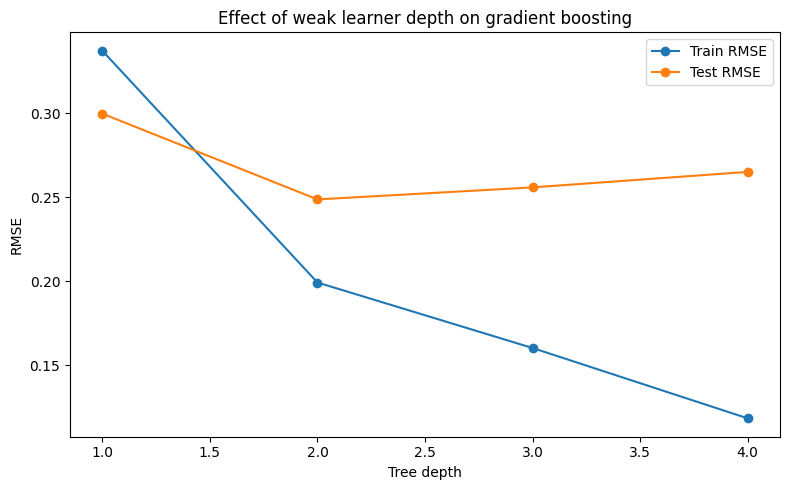

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(depth_df["max_depth"], depth_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(depth_df["max_depth"], depth_df["test_rmse"], marker="o", label="Test RMSE")
plt.xlabel("Tree depth")
plt.ylabel("RMSE")
plt.title("Effect of weak learner depth on gradient boosting")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# A real dataset makes the tutorial more convincing than a toy example alone.
data = load_diabetes()
X_real = data.data
y_real = data.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.3, random_state=RANDOM_STATE
)

real_rows = []

for n in [10, 50, 100, 200]:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=2,
        random_state=RANDOM_STATE
    )

    metrics = evaluate_regressor(model, X_train_r, X_test_r, y_train_r, y_test_r)
    real_rows.append({
        "n_estimators": n,
        **metrics
    })

real_df = pd.DataFrame(real_rows)
real_df

,n_estimators,train_rmse,test_rmse,train_r2,test_r2
0,10,58.871921,56.817862,0.436281,0.401985
1,50,45.401324,52.094342,0.664739,0.497283
2,100,40.102288,52.633063,0.738432,0.486832
3,200,33.438768,53.792815,0.818136,0.463968


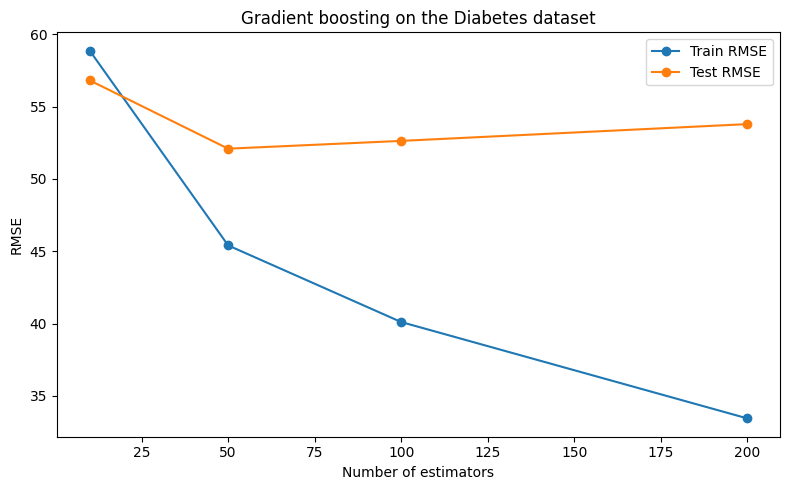

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(real_df["n_estimators"], real_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(real_df["n_estimators"], real_df["test_rmse"], marker="o", label="Test RMSE")
plt.xlabel("Number of estimators")
plt.ylabel("RMSE")
plt.title("Gradient boosting on the Diabetes dataset")
plt.legend()
plt.tight_layout()
plt.show()